# EOS Table Generator

Inverts the neural-network equation of state (EOS) on an $(\varepsilon, n_B)$ grid.
For each grid point the code solves for $(T, \mu_B, \mu_Q, \mu_S)$ using
damped Newton iterations, then writes the result to `ExampleEOS.dat`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from src.chi_module import ChiRatioParam  # lattice QCD chi0 parametrisation


In [2]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = "cpu"
print("Using device:", device)


Using device: cpu


## Rescaling constants

The network output is the dimensionless ratio $p/T^4$.
The physical pressure is reconstructed as
$$P = \beta \cdot P_{\theta}(T,\mu_B,\mu_Q,\mu_S)\,\cdot(T+\Delta T)^2 + P_{\rm lQCD}(T),$$
where $\beta$ and $\Delta T$ are fixed fit parameters.

In [3]:
beta   = 3.8388147316060315  
deltaT = 0.05    # in GeV           


## Lattice QCD baseline ($\mu_B = 0$)

The network learns *corrections* on top of the lattice QCD pressure at
vanishing chemical potential. `Plat` returns the lQCD pressure in
units of $\text{fm}^{-4}$ (conversion factor $5.068^3$ from $\text{GeV}^3$).
`entropy` is obtained by numerical differentiation: $s = \partial P/\partial T$.

In [4]:
def Plat(T, muB=0.0, muQ=0.0, muS=0.0):
    """Lattice QCD pressure P(T) at mu=0 in units of fm^{-4}."""
    device = T.device if isinstance(T, torch.Tensor) else "cpu"
    T = torch.as_tensor(T, dtype=torch.float64, device=device)
    chi_param = ChiRatioParam("chi0", device=device)
    p = chi_param(T)                        # dimensionless p/T^4
    return p * T**4 * (5.068**3)


def entropy(T, muB=0.0, muQ=0.0, muS=0.0, dT=1e-4):
    """Entropy density s = dP/dT via central finite difference  [fm^{-4}/GeV]."""
    device = T.device if isinstance(T, torch.Tensor) else "cpu"
    T = torch.as_tensor(T, dtype=torch.float64, device=device)
    return (Plat(T + dT) - Plat(T - dT)) / (2 * dT)


## Neural-network EOS


In [5]:
class ResidualBlock(nn.Module):
    """Single residual layer: x -> x + tanh(Wx + b)."""
    def __init__(self, dim):
        super().__init__()
        self.fc  = nn.Linear(dim, dim)
        self.act = nn.Tanh()

    def forward(self, x):
        return x + self.act(self.fc(x))


class EOSNetDeep(nn.Module):
    """
    Deep residual network for the equation of state.

    Input:  (T, muB, muQ, muS)  in GeV
    Output: scalar residual pressure  p_res / [beta*(T+deltaT)^2]
    """
    def __init__(self, input_dim=4, hidden_dim=64, output_dim=1, n_layers=16):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.blocks      = nn.ModuleList([ResidualBlock(hidden_dim) for _ in range(n_layers)])
        self.out_layer   = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = torch.tanh(self.input_layer(x))
        for block in self.blocks:
            x = block(x)
        return self.out_layer(x)


# ── load weights ─────────────────────────────────────────────────────────────
filename = "model/EOSNetDeep_rezNet.pth"
if not os.path.exists(filename):
    raise FileNotFoundError(f"No saved model found at: {filename}")

modelForward = EOSNetDeep(input_dim=4, hidden_dim=128, output_dim=1, n_layers=24).to(device)
modelForward.load_state_dict(torch.load(filename, map_location=device))
modelForward.eval()
print(f"Loaded {filename}")


Loaded model/EOSNetDeep_rezNet.pth


## Observable generator

All thermodynamic observables follow from the pressure via
standard thermodynamic identities:
$$n_i = \frac{\partial P}{\partial \mu_i}, \qquad
s = \frac{\partial P}{\partial T}, \qquad
\varepsilon = Ts + \sum_i \mu_i n_i - P.$$
The gradient $\partial P/\partial X$ is computed by automatic differentiation through the network plus the analytic lQCD term.

In [6]:
def generate_obs(X_tensor):
    """
    Return (eps, nB, nQ, nS, P) for a batch of thermodynamic states.

    Parameters
    ----------
    X_tensor : (N, 4) tensor  -- columns: T, muB, muQ, muS  [GeV]

    Returns
    -------
    (N, 5) tensor  -- eps, nB, nQ, nS  [fm^{-4}], P  [fm^{-4}]
    """
    X_tensor = X_tensor.detach().requires_grad_(True)

    with torch.enable_grad():
        y_pred = modelForward(X_tensor)                   # residual p_res / scale

        # gradient of the network output w.r.t. all four inputs simultaneously
        dP_dX = torch.autograd.grad(
            outputs=y_pred[:, 0].sum(),
            inputs=X_tensor,
            create_graph=False,
        )[0]

    T   = X_tensor[:, 0].detach()
    muB = X_tensor[:, 1].detach()
    muQ = X_tensor[:, 2].detach()
    muS = X_tensor[:, 3].detach()

    scale = beta * (T + deltaT) ** 2   # [GeV^2]; converts net output to fm^{-4}

    # conserved-charge densities  n_i = dP/d mu_i
    nB = dP_dX[:, 1].detach() * scale
    nQ = dP_dX[:, 2].detach() * scale
    nS = dP_dX[:, 3].detach() * scale

    # full pressure = network correction + lQCD baseline
    P = y_pred[:, 0].detach() * scale + Plat(T).to(device)

    # entropy density  s = dP/dT  (chain rule through scale factor)
    s = (dP_dX[:, 0].detach() * scale
         + 2 * y_pred[:, 0].detach() * beta * (T + deltaT)
         + entropy(T).to(device))

    eps = T * s + muB * nB + muQ * nQ + muS * nS - P   # Euler relation

    return torch.stack((eps, nB, nQ, nS, P), dim=1)


## $(\varepsilon,\, n_B)$ grid

The EOS table is built on a uniform grid in $\varepsilon$ and $n_B$.  
The isospin and strangeness constraints
$$n_Q = 0.4\,n_B, \qquad n_S = 0$$
are imposed inside `eval_F` to match the isospin-symmetric nuclear matter condition ($Z/A \approx 0.4$).

Define `eps_vals` and `nB_vals` (in fm$^{-4}$) before running the next cell.


In [7]:
# Define the grid ranges here ---------------------------------------------------
# eps_vals = np.linspace(...)   # energy density  [fm^{-4}]
# nB_vals  = np.linspace(...)   # baryon density  [fm^{-4}]
# ------------------------------------------------------------------------------


eps_vals = np.linspace(0, 1.0, 11)  
nB_vals  = np.linspace(-0.1, 0.6, 18)  

EPS, NB = np.meshgrid(eps_vals, nB_vals, indexing="ij")
eps_sel  = EPS.reshape(-1)
nB_sel   = NB.reshape(-1)
print(f"Grid shape: {EPS.shape}  |  total points: {len(eps_sel)}")

# Flatten to 1-D target arrays for the inversion
eps_target = torch.tensor(eps_sel, dtype=torch.float32, device=device)
nB_target  = torch.tensor(nB_sel,  dtype=torch.float32, device=device)


Grid shape: (11, 18)  |  total points: 198


## Newton inversion

For each grid point $(\varepsilon^*, n_B^*)$ we solve the nonlinear system
$$F(T,\mu_B,\mu_Q,\mu_S) = \begin{pmatrix} \varepsilon - \varepsilon^* \\\\ n_B - n_B^* \\\\ n_Q - 0.4\,n_B \\\\ n_S \end{pmatrix} = 0$$
with damped Newton steps. The Jacobian is computed by finite differences across the full batch in parallel.


In [8]:
# ── residual vector ───────────────────────────────────────────────────────────
def eval_F(x):
    obs = generate_obs(x)
    eps, nB, nQ, nS = obs[:, 0], obs[:, 1], obs[:, 2], obs[:, 3]
    return torch.stack([
        eps - eps_target,
        nB  - nB_target,
        nQ  - 0.4 * nB,   # isospin constraint
        nS,                # strangeness neutrality
    ], dim=1).to(dtype=torch.float32)


# ── finite-difference Jacobian (batched over all grid points) ─────────────────
def jacobian_fd(x, h=1e-2):
    N, D = x.shape
    J = torch.zeros(N, D, D, device=device, dtype=torch.float32)
    for i in range(D):
        dx = torch.zeros_like(x)
        dx[:, i] = h
        J[:, :, i] = (eval_F(x + dx) - eval_F(x - dx)) / (2 * h)
    return J


# ── initial guess ─────────────────────────────────────────────────────────────
x = torch.zeros((len(eps_sel), 4), device=device, dtype=torch.float32)
x[:, 0] = 0.15   # T    [GeV]
x[:, 1] = 0.40   # muB  [GeV]
x[:, 2] = 0.00   # muQ  [GeV]
x[:, 3] = 0.00   # muS  [GeV]

# ── damped Newton loop ────────────────────────────────────────────────────────
MAX_ITER = 50
DAMPING  = 0.5    # step size < 1 prevents overshooting in highly nonlinear regions

for q in range(MAX_ITER):
    F = eval_F(x)
    J = jacobian_fd(x)
    dx = torch.linalg.solve(J, F.unsqueeze(-1)).squeeze(-1)
    x  = x - DAMPING * dx

    # hard bounds keep x inside the training domain of the network
    x[:, 0].clamp_(0.02, 0.60)   # T
    x[:, 1].clamp_(-0.05, 1.05)  # muB
    x[:, 2].clamp_(-0.05, 0.05)  # muQ
    x[:, 3].clamp_(-0.05, 0.40)  # muS

    res_norm  = F.detach().cpu().numpy()
    res_norm  = np.linalg.norm(res_norm, axis=1)
    good_mask = res_norm < 1e-3

    if q % 10 == 0:
        print(f"iter {q:2d}  |  max={res_norm.max():.2e}  mean={res_norm.mean():.2e}"
              f"  |  converged: {good_mask.sum()}/{len(res_norm)}")

    if good_mask.all() and res_norm.max() < 1e-6:
        print("All points converged.")
        break

T_sol, muB_sol, muQ_sol, muS_sol = x.T.detach().cpu().numpy()
residual_norm = np.linalg.norm(eval_F(x).detach().cpu().numpy(), axis=1)

good = residual_norm < 1e-3
print(f"\nFinal: {good.mean():.1%} of points converged"
      f"  |  mean residual {residual_norm[good].mean():.2e}"
      f"  |  max residual {residual_norm[good].max():.2e}")


iter  0  |  max=6.66e-01  mean=3.76e-01  |  converged: 0/198
iter 10  |  max=8.67e-01  mean=1.57e-01  |  converged: 98/198
iter 20  |  max=2.75e+00  mean=1.70e-01  |  converged: 116/198
iter 30  |  max=2.28e+00  mean=1.79e-01  |  converged: 116/198
iter 40  |  max=1.00e+00  mean=1.63e-01  |  converged: 116/198

Final: 58.6% of points converged  |  mean residual 1.53e-07  |  max residual 4.22e-07


## Diagnostic: converged points

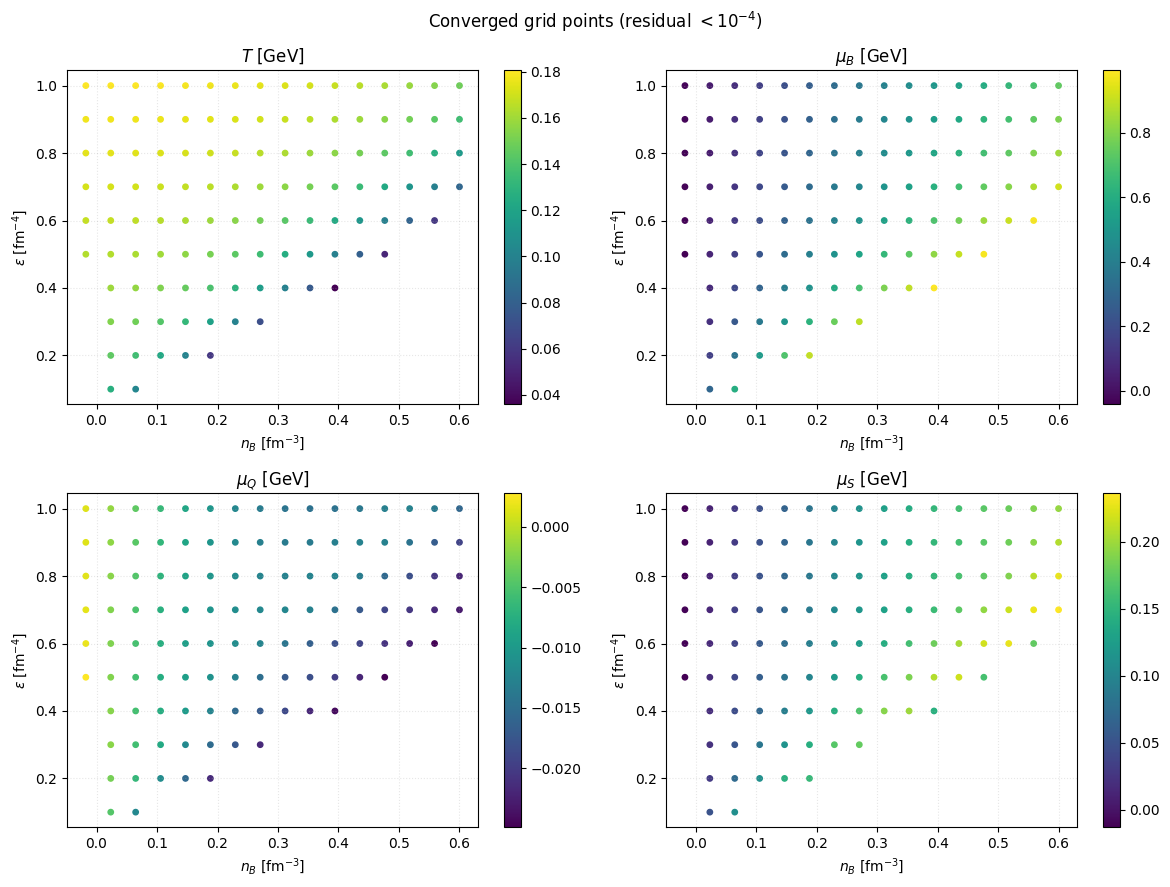

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
good = residual_norm < 1e-4   # tighter cut for the plot

def panel(ax, c, title):
    sc = ax.scatter(nB_sel[good], eps_sel[good], c=c[good], cmap="viridis", s=15)
    plt.colorbar(sc, ax=ax)
    ax.set(title=title, xlabel=r"$n_B$ [fm$^{-3}$]", ylabel=r"$\varepsilon$ [fm$^{-4}$]")
    ax.grid(linestyle=":", alpha=0.3)

panel(axes[0, 0], T_sol,   r"$T$ [GeV]")
panel(axes[0, 1], muB_sol, r"$\mu_B$ [GeV]")
panel(axes[1, 0], muQ_sol, r"$\mu_Q$ [GeV]")
panel(axes[1, 1], muS_sol, r"$\mu_S$ [GeV]")

plt.suptitle("Converged grid points (residual $< 10^{-4}$)")
plt.tight_layout()
plt.show()


## Nearest-neighbour fallback for unconverged points

Points that did not converge are seeded from the nearest converged neighbour
in $(\\varepsilon, n_B)$ space and the Newton loop is re-run. This avoids holes
in the table while keeping the residual small almost everywhere.


In [10]:
bad_mask  = residual_norm >= 1e-4
good_idx  = np.where(~bad_mask)[0]

if bad_mask.any() and len(good_idx) > 0:
    x_np   = x.detach().cpu().numpy()
    coords = np.stack([eps_sel, nB_sel], axis=1)

    for i in np.where(bad_mask)[0]:
        d       = np.sum((coords[good_idx] - coords[i]) ** 2, axis=1)
        nearest = good_idx[np.argmin(d)]
        x_np[i] = x_np[nearest]   # warm-start from closest good solution

    x = torch.tensor(x_np, device=device, dtype=torch.float32)
    print(f"Re-seeded {bad_mask.sum()} unconverged points.")


Re-seeded 82 unconverged points.


In [11]:
# optional second pass after re-seeding
for q in range(MAX_ITER):
    F  = eval_F(x)
    J  = jacobian_fd(x)
    dx = torch.linalg.solve(J, F.unsqueeze(-1)).squeeze(-1)
    x  = x - DAMPING * dx
    x[:, 0].clamp_(0.02, 0.60)
    x[:, 1].clamp_(-0.05, 1.05)
    x[:, 2].clamp_(-0.05, 0.05)
    x[:, 3].clamp_(-0.05, 0.40)
    res_norm  = np.linalg.norm(F.detach().cpu().numpy(), axis=1)
    if res_norm.max() < 1e-6:
        break
print(f"After re-seed pass: max residual {res_norm.max():.2e}")


After re-seed pass: max residual 6.58e+01


## Final solution over the full grid

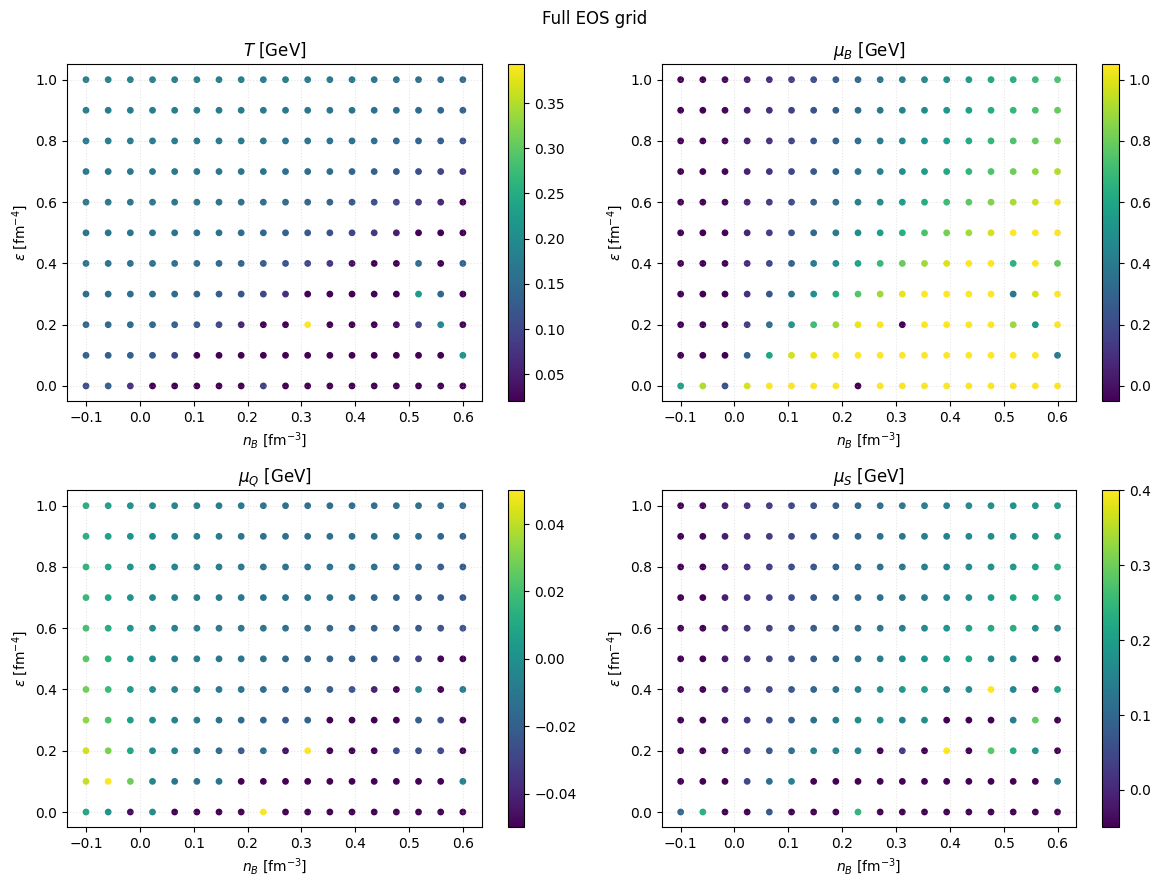

In [12]:
T_sol   = x[:, 0].detach().cpu().numpy()
muB_sol = x[:, 1].detach().cpu().numpy()
muQ_sol = x[:, 2].detach().cpu().numpy()
muS_sol = x[:, 3].detach().cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

def panel(ax, c, title):
    sc = ax.scatter(nB_sel, eps_sel, c=c, cmap="viridis", s=15)
    plt.colorbar(sc, ax=ax)
    ax.set(title=title, xlabel=r"$n_B$ [fm$^{-3}$]", ylabel=r"$\varepsilon$ [fm$^{-4}$]")
    ax.grid(linestyle=":", alpha=0.3)

panel(axes[0, 0], T_sol,   r"$T$ [GeV]")
panel(axes[0, 1], muB_sol, r"$\mu_B$ [GeV]")
panel(axes[1, 0], muQ_sol, r"$\mu_Q$ [GeV]")
panel(axes[1, 1], muS_sol, r"$\mu_S$ [GeV]")

plt.suptitle("Full EOS grid")
plt.tight_layout()
plt.show()


## Vacuum boundary condition and output

At $\varepsilon \to 0$ the EOS must approach the vacuum ($T=0$, $P=0$).
Points below $\varepsilon < 10^{-4}\\,\text{fm}^{-4}$ are set to vacuum by hand
before writing the table.

Output columns: `T  muB  eps  nB  muQ  muS  P  residual`


In [13]:
x_tensor = torch.tensor(
    np.stack([T_sol, muB_sol, muQ_sol, muS_sol], axis=1),
    dtype=torch.float32, device=device
)

vacuum_mask = eps_target < 1e-4

# zero out temperature in the vacuum region
T_vac = torch.where(vacuum_mask, torch.zeros_like(x_tensor[:, 0]), x_tensor[:, 0])
x_fixed = torch.stack([T_vac, x_tensor[:, 1], x_tensor[:, 2], x_tensor[:, 3]], dim=1)

obs     = generate_obs(x_fixed)
P_model = obs[:, 4]
F_final = eval_F(x_fixed)
res     = torch.linalg.norm(F_final, dim=1)

# enforce P = 0 in vacuum; mark vacuum residual as 1 (trivially satisfied)
P_model = torch.where(vacuum_mask, torch.zeros_like(P_model), P_model)
res     = torch.where(vacuum_mask, torch.ones_like(res), res)

out = torch.stack([
    T_vac, x_tensor[:, 1],   # T, muB
    eps_target, nB_target,    # grid values kept exact
    x_tensor[:, 2], x_tensor[:, 3],  # muQ, muS
    P_model, res
], dim=1).detach().cpu().numpy()

# sort by (nB, eps) for a structured table
order = np.lexsort((out[:, 2], out[:, 3]))
out   = out[order]

np.savetxt("ExampleEOS.dat", out, fmt="%.6f",
           header="T[GeV]  muB[GeV]  eps[fm-4]  nB[fm-3]  muQ[GeV]  muS[GeV]  P[fm-4]  residual")
print("Saved: ExampleEOS.dat")


Saved: ExampleEOS.dat
